In [71]:
#import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score


In [72]:
# Load the synthetic dataset
df = pd.read_csv('synthetic_T1_diabetes_data.csv')

# Quick check
df.head()


,Historic Glucose (mmol/L),Scan Glucose (mmol/L),Rapid-Acting Insulin (units),Long-Acting Insulin (units),Carbohydrates (grams),Thirst,Nausea,Weakness,Vomiting,Fatigue,Shakiness,Condition
0,9.0,2.5,5,17,44,0,0,1,0,1,1,0
1,20.0,2.5,15,18,98,0,1,1,0,1,1,0
2,5.9,2.5,3,20,26,0,0,1,0,1,1,0
3,7.0,3.7,3,14,16,0,0,0,0,1,1,0
4,15.2,2.8,9,11,63,0,0,1,0,1,1,0


In [73]:

# Map numeric labels to condition names
condition_map = {0: "Hypoglycemia", 1: "Normal", 2: "Hyperglycemia", 3: "DKA"}
y = df['Condition']

# Unique numeric labels
unique_labels = y.unique()
print("Unique numeric labels:", unique_labels)

# Unique condition names
unique_conditions = [condition_map[label] for label in unique_labels]
print("Unique conditions:", unique_conditions)


Unique numeric labels: [0 1 2 3]
Unique conditions: ['Hypoglycemia', 'Normal', 'Hyperglycemia', 'DKA']


/tmp/ipykernel_11937/3109872007.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Condition', data=df, order=sorted(df['Condition'].unique()), palette='viridis')


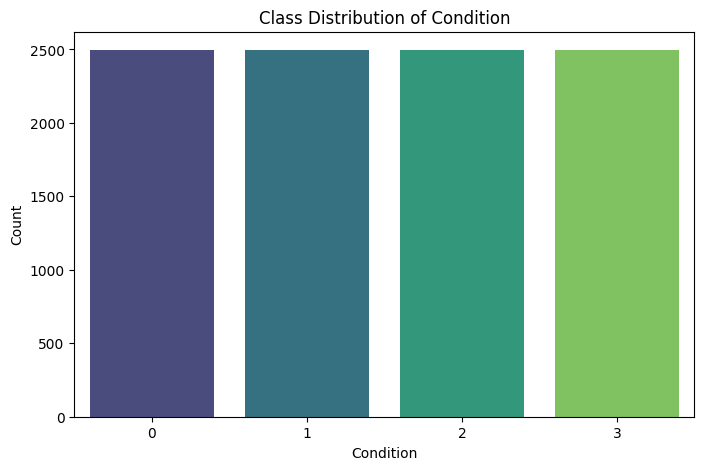

In [74]:
# Visualize class distribution

plt.figure(figsize=(8,5))
sns.countplot(x='Condition', data=df, order=sorted(df['Condition'].unique()), palette='viridis')
plt.title('Class Distribution of Condition')
plt.xlabel('Condition')
plt.ylabel('Count')
plt.show()


In [75]:
# Features (all columns except 'Condition')
X = df.drop('Condition', axis=1)

# Labels (Condition column)
y = df['Condition']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [76]:
# Initialize the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [77]:
# Read the CSV using tab separator
real_df = pd.read_csv('real_data.csv', sep='\t')

# Check column names
print(real_df.columns)

# Check column names

print("Columns in file:\n", real_df.columns.tolist())


Index(['ID', 'Time', 'Record Type', 'Historic Glucose (mmol/L)',
       'Scan Glucose (mmol/L)', 'Non-numeric Rapid-Acting Insulin',
       'Rapid-Acting Insulin (units)', 'Non-numeric Food',
       'Carbohydrates (grams)', 'Non-numeric Long-Acting Insulin',
       'Long-Acting Insulin (units)', 'Notes', 'Strip Glucose (mmol/L)',
       'Ketone (mmol/L)', 'Meal Insulin (units)', 'Correction Insulin (units)',
       'User Change Insulin (units)', 'Previous Time', 'Updated Time'],
      dtype='object')
Columns in file:
 ['ID', 'Time', 'Record Type', 'Historic Glucose (mmol/L)', 'Scan Glucose (mmol/L)', 'Non-numeric Rapid-Acting Insulin', 'Rapid-Acting Insulin (units)', 'Non-numeric Food', 'Carbohydrates (grams)', 'Non-numeric Long-Acting Insulin', 'Long-Acting Insulin (units)', 'Notes', 'Strip Glucose (mmol/L)', 'Ketone (mmol/L)', 'Meal Insulin (units)', 'Correction Insulin (units)', 'User Change Insulin (units)', 'Previous Time', 'Updated Time']


In [78]:
# Select only columns relevant to the model
needed_cols = [
    'Historic Glucose (mmol/L)',
    'Scan Glucose (mmol/L)',
    'Rapid-Acting Insulin (units)',
    'Long-Acting Insulin (units)',
    'Carbohydrates (grams)'
]

# Keep only required columns
real_df = real_df[needed_cols]

# Check for missing values
print("Missing values before filling:\n", real_df.isnull().sum())


Missing values before filling:
 Historic Glucose (mmol/L)        1676
Scan Glucose (mmol/L)           11632
Rapid-Acting Insulin (units)    12788
Long-Acting Insulin (units)     12920
Carbohydrates (grams)           12781
dtype: int64


In [79]:
#  — Clean and replace zeros with median value
import numpy as np

# Replace zeros with NaN for easy processing
real_df['Historic Glucose (mmol/L)'] = real_df['Historic Glucose (mmol/L)'].replace(0, np.nan)

# Compute median of valid values
median_glucose = real_df['Historic Glucose (mmol/L)'].median()

# Fill missing values with median
real_df['Historic Glucose (mmol/L)'] = real_df['Historic Glucose (mmol/L)'].fillna(median_glucose)

print(" Historic Glucose cleaned — zeros replaced with median value:", median_glucose)


 Historic Glucose cleaned — zeros replaced with median value: 7.7


In [80]:
#  — Fix Scan Glucose zeros using Historic Glucose or median
# Replace NaN or 0 values in Scan Glucose
median_scan = real_df['Scan Glucose (mmol/L)'].median()

# First fill zeros or NaN using Historic Glucose
real_df['Scan Glucose (mmol/L)'] = real_df.apply(
    lambda row: row['Historic Glucose (mmol/L)']
    if pd.isna(row['Scan Glucose (mmol/L)']) or row['Scan Glucose (mmol/L)'] == 0
    else row['Scan Glucose (mmol/L)'],
    axis=1
)

# Fill any remaining NaN or 0 with the median
real_df['Scan Glucose (mmol/L)'] = real_df['Scan Glucose (mmol/L)'].replace(0, median_scan)
real_df['Scan Glucose (mmol/L)'] = real_df['Scan Glucose (mmol/L)'].fillna(median_scan)

print(" Scan Glucose fully cleaned — no NaNs or zeros remain!")
print(real_df['Scan Glucose (mmol/L)'].isna().sum(), "missing values remain")


# Confirm fix
print(" Scan Glucose cleaned — summary:")
print(real_df[['Historic Glucose (mmol/L)', 'Scan Glucose (mmol/L)']].describe())


 Scan Glucose fully cleaned — no NaNs or zeros remain!
0 missing values remain
 Scan Glucose cleaned — summary:
       Historic Glucose (mmol/L)  Scan Glucose (mmol/L)
count               12949.000000           12949.000000
mean                    8.085667               8.197081
std                     2.866533               3.027733
min                     2.200000               2.200000
25%                     6.200000               6.000000
50%                     7.700000               7.700000
75%                     9.600000              10.000000
max                    24.200000              24.200000


In [81]:
# Final check: fill any new NaNs after combining Scan and Historic
real_df['Historic Glucose (mmol/L)'] = real_df['Historic Glucose (mmol/L)'].fillna(
    real_df['Historic Glucose (mmol/L)'].median()
)
real_df['Scan Glucose (mmol/L)'] = real_df['Scan Glucose (mmol/L)'].fillna(
    real_df['Scan Glucose (mmol/L)'].median()
)

print("Final glucose cleaning done — no NaNs remain.")


Final glucose cleaning done — no NaNs remain.


In [82]:
#FEATURE ENGINEERING: ASSIGN SYMPTOMS BASED ON GLUCOSE LEVELS

# Create symptom columns initialized to 0
symptom_cols = ['Thirst', 'Nausea', 'Weakness', 'Vomiting', 'Fatigue', 'Shakiness']
for col in symptom_cols:
    real_df[col] = 0

# Apply logic based on glucose levels
for i, row in real_df.iterrows():
    glucose = row['Scan Glucose (mmol/L)']
    
    # Hypoglycemia (<4.0)
    if glucose < 4.0:
        real_df.at[i, 'Shakiness'] = 1
        real_df.at[i, 'Weakness'] = 1
        real_df.at[i, 'Fatigue'] = 1
    
    # NORMAL RANGE (4.0-7.0)
    elif 4.0 <= glucose < 7.0:
        # Borderline low (4.0-5.0) might have mild
        if glucose < 5.0:
            real_df.at[i, 'Shakiness'] = 1
        # # Borderline high normal: Mild fatigue for mid-normal
        elif glucose > 6.5:
            real_df.at[i, 'Fatigue'] = 1
    
    # Hyperglycemia (7.0-12.0) 
    elif 7.0 <= glucose < 12.0: 
        real_df.at[i, 'Thirst'] = 1
        real_df.at[i, 'Fatigue'] = 1
        # Add Nausea for higher hyperglycemia
        if glucose >= 10.0:
            real_df.at[i, 'Nausea'] = 1
        # Weakness may appear in upper hyperglycemia
        if glucose >= 11.0:
            real_df.at[i, 'Weakness'] = 1
    
    # DKA (≥12.0)
    elif glucose >= 12.0: 
        real_df.at[i, 'Thirst'] = 1
        real_df.at[i, 'Nausea'] = 1
        real_df.at[i, 'Vomiting'] = 1
        real_df.at[i, 'Fatigue'] = 1
        real_df.at[i, 'Weakness'] = 1

print("Symptoms assigned successfully!")
print("\nSample data:")
print(real_df[['Scan Glucose (mmol/L)', 'Shakiness', 'Thirst', 'Fatigue', 'Weakness', 'Nausea', 'Vomiting']].head())


Symptoms assigned successfully!

Sample data:
   Scan Glucose (mmol/L)  Shakiness  Thirst  Fatigue  Weakness  Nausea  \
0                    8.8          0       1        1         0       0   
1                   10.4          0       1        1         0       1   
2                    7.7          0       1        1         0       0   
3                   14.2          0       1        1         1       1   
4                   14.5          0       1        1         1       1   

   Vomiting  
0         0  
1         0  
2         0  
3         1  
4         1  


In [83]:
# Show the updated dataframe with all important columns
print("Final cleaned and symptom-augmented dataset:\n")
real_df[
    [
        'Historic Glucose (mmol/L)',
        'Scan Glucose (mmol/L)',
        'Rapid-Acting Insulin (units)',
        'Long-Acting Insulin (units)',
        'Carbohydrates (grams)',
        'Thirst',
        'Nausea',
        'Weakness',
        'Vomiting',
        'Fatigue',
        'Shakiness'
    ]
].head(20) 


Final cleaned and symptom-augmented dataset:



,Historic Glucose (mmol/L),Scan Glucose (mmol/L),Rapid-Acting Insulin (units),Long-Acting Insulin (units),Carbohydrates (grams),Thirst,Nausea,Weakness,Vomiting,Fatigue,Shakiness
0,7.7,8.8,NaN,NaN,NaN,1,0,0,0,1,0
1,7.7,10.4,NaN,NaN,NaN,1,1,0,0,1,0
2,7.7,7.7,2.0,NaN,NaN,1,0,0,0,1,0
3,7.7,14.2,NaN,NaN,NaN,1,1,1,1,1,0
4,7.7,14.5,NaN,NaN,NaN,1,1,1,1,1,0
5,7.7,6.2,NaN,NaN,NaN,0,0,0,0,0,0
6,7.7,6.2,NaN,NaN,NaN,0,0,0,0,0,0
7,7.7,7.7,NaN,12.0,NaN,1,0,0,0,1,0
8,7.7,6.8,NaN,NaN,NaN,0,0,0,0,1,0
9,7.7,6.2,NaN,NaN,NaN,0,0,0,0,0,0


In [84]:
#  — Arrange columns in the same order as training
feature_cols = [
    'Historic Glucose (mmol/L)',
    'Scan Glucose (mmol/L)',
    'Rapid-Acting Insulin (units)',
    'Long-Acting Insulin (units)',
    'Carbohydrates (grams)'
] + symptom_cols

real_df = real_df[feature_cols]

print(" Final dataset ready for prediction:")
display(real_df.head())


 Final dataset ready for prediction:


,Historic Glucose (mmol/L),Scan Glucose (mmol/L),Rapid-Acting Insulin (units),Long-Acting Insulin (units),Carbohydrates (grams),Thirst,Nausea,Weakness,Vomiting,Fatigue,Shakiness
0,7.7,8.8,NaN,NaN,NaN,1,0,0,0,1,0
1,7.7,10.4,NaN,NaN,NaN,1,1,0,0,1,0
2,7.7,7.7,2.0,NaN,NaN,1,0,0,0,1,0
3,7.7,14.2,NaN,NaN,NaN,1,1,1,1,1,0
4,7.7,14.5,NaN,NaN,NaN,1,1,1,1,1,0


In [85]:
# Fill insulin and carb NaNs with 0 (means no dose or no meal)
real_df['Rapid-Acting Insulin (units)'] = real_df['Rapid-Acting Insulin (units)'].fillna(0)
real_df['Long-Acting Insulin (units)'] = real_df['Long-Acting Insulin (units)'].fillna(0)
real_df['Carbohydrates (grams)'] = real_df['Carbohydrates (grams)'].fillna(0)


print("Missing values after cleaning:\n", real_df.isnull().sum())
real_df.head()

Missing values after cleaning:
 Historic Glucose (mmol/L)       0
Scan Glucose (mmol/L)           0
Rapid-Acting Insulin (units)    0
Long-Acting Insulin (units)     0
Carbohydrates (grams)           0
Thirst                          0
Nausea                          0
Weakness                        0
Vomiting                        0
Fatigue                         0
Shakiness                       0
dtype: int64


,Historic Glucose (mmol/L),Scan Glucose (mmol/L),Rapid-Acting Insulin (units),Long-Acting Insulin (units),Carbohydrates (grams),Thirst,Nausea,Weakness,Vomiting,Fatigue,Shakiness
0,7.7,8.8,0.0,0.0,0.0,1,0,0,0,1,0
1,7.7,10.4,0.0,0.0,0.0,1,1,0,0,1,0
2,7.7,7.7,2.0,0.0,0.0,1,0,0,0,1,0
3,7.7,14.2,0.0,0.0,0.0,1,1,1,1,1,0
4,7.7,14.5,0.0,0.0,0.0,1,1,1,1,1,0


In [86]:
# Condition assignment function with updated glucose ranges and soft symptom influence


def assign_condition(glucose, thirst, nausea, vomiting, weakness, fatigue, shakiness):
    """
    Clinically aligned condition assignment with soft symptom influence.
    Uses updated glucose ranges from the synthetic generator:
        Hypo: <4.0
        Normal: 4.0–7.0
        Hyper: 7.0–12.0
        DKA: ≥12.0
    Symptom influence is incorporated for borderline cases.
    """

    # Fixed thresholds: fixed glucose level boundaries (in mmol/L) for different metabolic states, based on clinical ranges used in T1D
    hypo_threshold = 4.0
    normal_upper = 7.0
    hyper_upper = 12.0
    dka_threshold = 12.0

    # Base glucose classification: gives an initial health state based on glucose level alone.
    if glucose < hypo_threshold:
        base_condition = 0  # Hypoglycemia
    elif glucose < normal_upper:
        base_condition = 1  # Normal
    elif glucose < hyper_upper:
        base_condition = 2  # Hyperglycemia
    else:
        base_condition = 3  # DKA


    # Soft Symptom Influence
    
    symptom_score = thirst + nausea + vomiting + weakness + fatigue + shakiness

    # Borderline Hypo/Normal (4.0–5.0)
    if 4.0 <= glucose <= 5.0:
        if symptom_score >= 2:
            return 0  # Lean Hypoglycemia
        elif symptom_score <= 1:
            return 1  # Normal
        else:
            return base_condition

    # Borderline Normal/Hyper (6.5–7.5)
    if 6.5 <= glucose <= 7.5:
        if symptom_score >= 2:
            return 2  # Slight Hyperglycemia
        elif symptom_score <= 1:
            return 1  # Normal
        else:
            return base_condition

    # Borderline Hyper/DKA (11.5–12.5)
    if 11.5 <= glucose <= 12.5:
        if symptom_score >= 4:
            return 3  # DKA
        elif symptom_score <= 2:
            return 2  # Hyperglycemia
        else:
            return base_condition

    # Severe symptom override
    if glucose >= 10.0 and symptom_score >= 5:
        return 3  # Clinical DKA

    # Default return
    return base_condition


# Apply to real data
print("Assigning conditions to real data (with updated glucose ranges and soft symptom weighting)...")
real_df['Condition'] = real_df.apply(
    lambda row: assign_condition(
        row['Scan Glucose (mmol/L)'],
        row['Thirst'],
        row['Nausea'],
        row['Vomiting'],
        row['Weakness'],
        row['Fatigue'],
        row['Shakiness']
    ),
    axis=1
)

print("Conditions assigned successfully!")
print("\nCondition distribution in real data:")
print(real_df['Condition'].value_counts().sort_index())


Assigning conditions to real data (with updated glucose ranges and soft symptom weighting)...
Conditions assigned successfully!

Condition distribution in real data:
Condition
0     660
1    4238
2    6207
3    1844
Name: count, dtype: int64


In [87]:
# Balance the dataset by downsampling to the smallest class size: Each condition contributes equally to performance metrics.Also,we fairly evaluate how the model performs across all classes.

from collections import Counter

# Check current distribution
print("Original class distribution:")
print(real_df['Condition'].value_counts().sort_index())

# find minimum class size
class_counts = Counter(real_df['Condition'])
min_samples = min(class_counts.values())

print(f"\nBalancing to minimum class size: {min_samples} samples per class")

# Balance the dataset by sampling
balanced_dfs = []
for condition_class in range(4):
    class_df = real_df[real_df['Condition'] == condition_class]
    
    if len(class_df) >= min_samples:
        sampled = class_df.sample(min_samples, random_state=42)
    else:
        print(f" Warning: Class {condition_class} has only {len(class_df)} samples")
        sampled = class_df  # Use all available
    
    balanced_dfs.append(sampled)

balanced_real_df = pd.concat(balanced_dfs, ignore_index=True)
print(f"\nBalanced dataset size: {len(balanced_real_df)}")
print("\nBalanced class distribution:")
print(balanced_real_df['Condition'].value_counts().sort_index())

Original class distribution:
Condition
0     660
1    4238
2    6207
3    1844
Name: count, dtype: int64

Balancing to minimum class size: 660 samples per class

Balanced dataset size: 2640

Balanced class distribution:
Condition
0    660
1    660
2    660
3    660
Name: count, dtype: int64


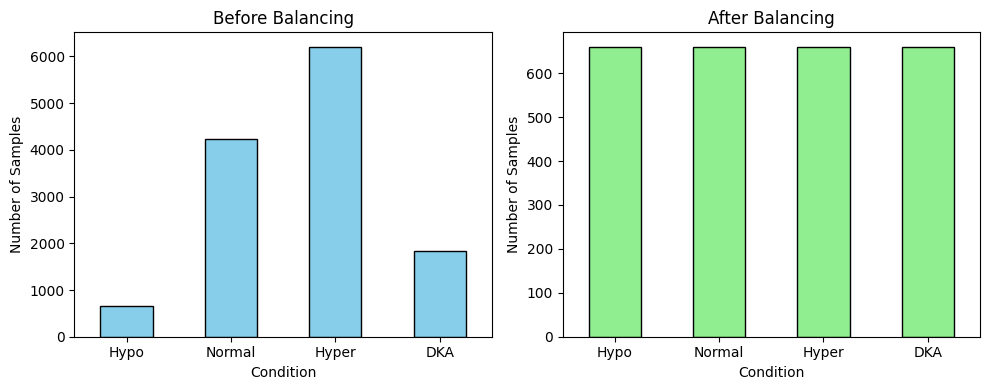

In [88]:
# Visualize class distribution before and after balancing

import matplotlib.pyplot as plt

# Plot before balancing
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
real_df['Condition'].value_counts().sort_index().plot(
    kind='bar', color='skyblue', edgecolor='black'
)
plt.title('Before Balancing')
plt.xlabel('Condition')
plt.ylabel('Number of Samples')
plt.xticks([0, 1, 2, 3], ['Hypo', 'Normal', 'Hyper', 'DKA'], rotation=0)

# Plot after balancing
plt.subplot(1, 2, 2)
balanced_real_df['Condition'].value_counts().sort_index().plot(
    kind='bar', color='lightgreen', edgecolor='black'
)
plt.title('After Balancing')
plt.xlabel('Condition')
plt.ylabel('Number of Samples')
plt.xticks([0, 1, 2, 3], ['Hypo', 'Normal', 'Hyper', 'DKA'], rotation=0)

plt.tight_layout()
plt.show()


In [89]:
# Ensure columns match training data exactly
X_real = balanced_real_df[X_train.columns]  # Use X_train columns order
y_true = balanced_real_df['Condition']

# Verify
print("Training features:", X_train.columns.tolist())
print("Real data features:", X_real.columns.tolist())
print("Features match:", list(X_train.columns) == list(X_real.columns))
print("\nMissing values:", X_real.isnull().sum().sum())

Training features: ['Historic Glucose (mmol/L)', 'Scan Glucose (mmol/L)', 'Rapid-Acting Insulin (units)', 'Long-Acting Insulin (units)', 'Carbohydrates (grams)', 'Thirst', 'Nausea', 'Weakness', 'Vomiting', 'Fatigue', 'Shakiness']
Real data features: ['Historic Glucose (mmol/L)', 'Scan Glucose (mmol/L)', 'Rapid-Acting Insulin (units)', 'Long-Acting Insulin (units)', 'Carbohydrates (grams)', 'Thirst', 'Nausea', 'Weakness', 'Vomiting', 'Fatigue', 'Shakiness']
Features match: True

Missing values: 0


 Model Accuracy on Balanced Real Data: 0.9768939393939394

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       660
           1       1.00      1.00      1.00       660
           2       0.92      1.00      0.96       660
           3       1.00      0.91      0.95       660

    accuracy                           0.98      2640
   macro avg       0.98      0.98      0.98      2640
weighted avg       0.98      0.98      0.98      2640



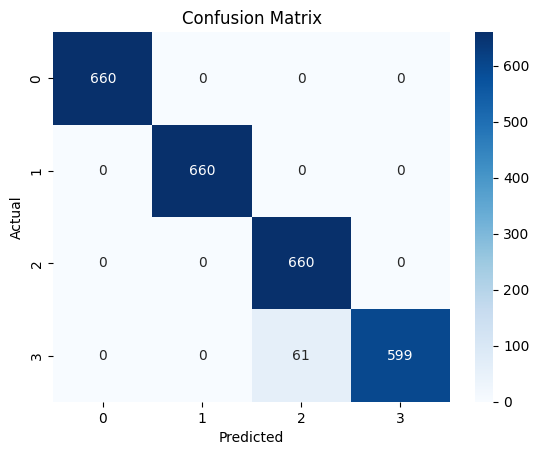

In [90]:
# Predict on balanced real data

y_pred_real = rf_model.predict(X_real)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Accuracy
accuracy = accuracy_score(y_true, y_pred_real)
print(" Model Accuracy on Balanced Real Data:", accuracy)

# Classification report
print("\nClassification Report:\n", classification_report(y_true, y_pred_real))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_real)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [91]:
# Compare glucose ranges
print("Synthetic data glucose range:", df['Scan Glucose (mmol/L)'].describe())
print("Real data glucose range:", real_df['Scan Glucose (mmol/L)'].describe())


Synthetic data glucose range: count    9984.000000
mean        8.912433
std         6.392002
min         2.500000
25%         3.975000
50%         6.950000
75%        11.880217
max        23.999120
Name: Scan Glucose (mmol/L), dtype: float64
Real data glucose range: count    12949.000000
mean         8.197081
std          3.027733
min          2.200000
25%          6.000000
50%          7.700000
75%         10.000000
max         24.200000
Name: Scan Glucose (mmol/L), dtype: float64


FEATURE IMPORTANCE ANALYSIS

Feature Importance Ranking:
                     Feature  Importance
       Scan Glucose (mmol/L)    0.468318
                   Shakiness    0.154404
                    Vomiting    0.077608
                      Thirst    0.065134
                      Nausea    0.051516
                     Fatigue    0.050195
       Carbohydrates (grams)    0.044806
                    Weakness    0.038400
   Historic Glucose (mmol/L)    0.028492
Rapid-Acting Insulin (units)    0.016265
 Long-Acting Insulin (units)    0.004861


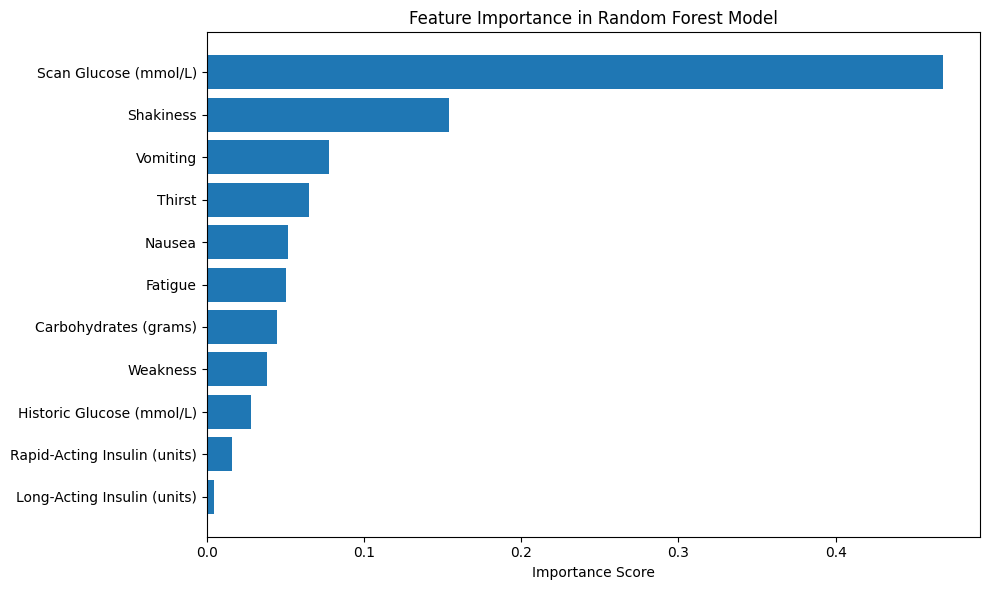

In [92]:

#  FEATURE IMPORTANCE ANALYSIS

print("FEATURE IMPORTANCE ANALYSIS")

# Get feature importances
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importance Ranking:")
print(feature_importance.to_string(index=False))

# Visualize feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel('Importance Score')
plt.title('Feature Importance in Random Forest Model')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [93]:

#  BASELINE MODEL PERFORMANCE


print(" BASELINE MODEL PERFORMANCE")


# Test set performance: how well your model learned from synthetic patterns.
y_pred_test = rf_model.predict(X_test)
baseline_test_acc = accuracy_score(y_test, y_pred_test)
print(f"\nTest Set Accuracy (All Features): {baseline_test_acc:.4f}")

# Real data performance: how well it transfers that learning to actual patient data.
y_pred_real = rf_model.predict(X_real)
baseline_real_acc = accuracy_score(y_true, y_pred_real)
print(f"Real Data Accuracy (All Features): {baseline_real_acc:.4f}")

 BASELINE MODEL PERFORMANCE

Test Set Accuracy (All Features): 0.9995
Real Data Accuracy (All Features): 0.9769


 ABLATION STUDY - REMOVING ONE FEATURE AT A TIME

 Testing WITHOUT: Historic Glucose (mmol/L)
   Test Accuracy: 0.9995 (Impact: +0.0000)
   Real Accuracy: 0.9580 (Impact: +0.0189)

 Testing WITHOUT: Scan Glucose (mmol/L)
   Test Accuracy: 0.9184 (Impact: +0.0811)
   Real Accuracy: 0.8587 (Impact: +0.1182)

 Testing WITHOUT: Rapid-Acting Insulin (units)
   Test Accuracy: 0.9995 (Impact: +0.0000)
   Real Accuracy: 0.9769 (Impact: +0.0000)

 Testing WITHOUT: Long-Acting Insulin (units)
   Test Accuracy: 0.9995 (Impact: +0.0000)
   Real Accuracy: 0.9580 (Impact: +0.0189)

 Testing WITHOUT: Carbohydrates (grams)
   Test Accuracy: 0.9995 (Impact: +0.0000)
   Real Accuracy: 0.9955 (Impact: -0.0186)

 Testing WITHOUT: Thirst
   Test Accuracy: 0.9995 (Impact: +0.0000)
   Real Accuracy: 0.9928 (Impact: -0.0159)

 Testing WITHOUT: Nausea
   Test Accuracy: 0.9995 (Impact: +0.0000)
   Real Accuracy: 0.8958 (Impact: +0.0811)

 Testing WITHOUT: Weakness
   Test Accuracy: 0.9990 (Impact: +0.0005)
   R

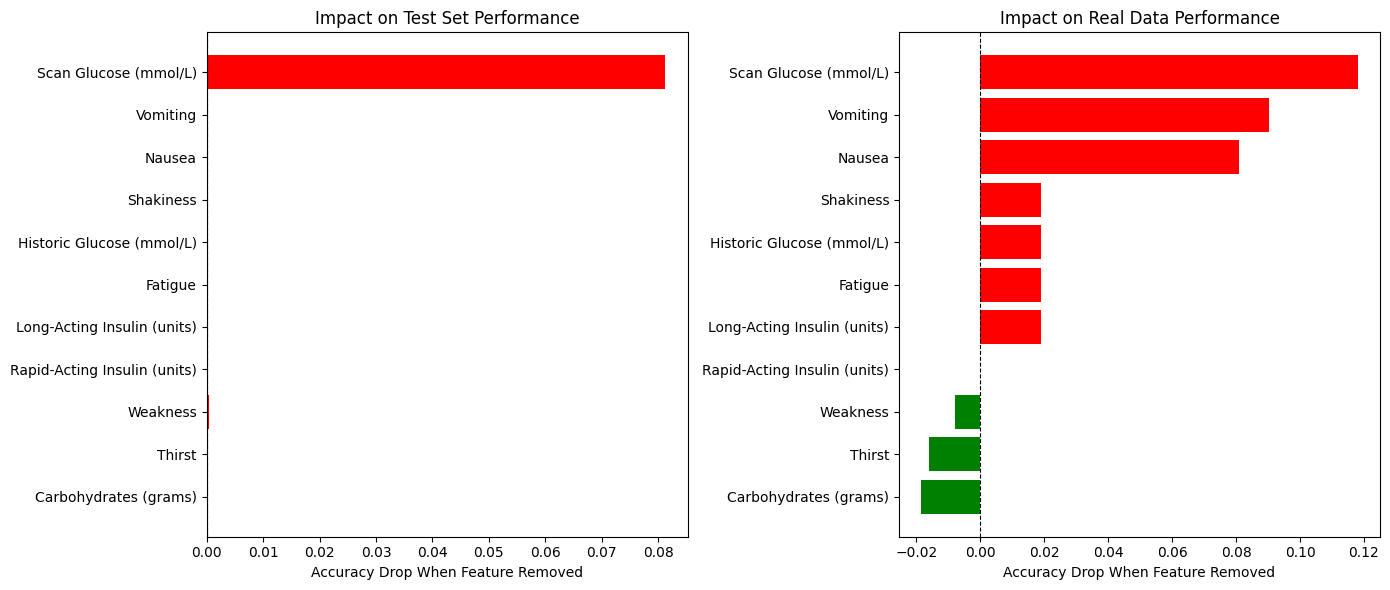

In [94]:

#  ABLATION STUDY - Remove One Feature at a Time


print(" ABLATION STUDY - REMOVING ONE FEATURE AT A TIME")


ablation_results = []

# Loop through each feature
for feature in X_train.columns:
    print(f"\n Testing WITHOUT: {feature}")
    
    # Create dataset without this feature
    X_train_ablated = X_train.drop(columns=[feature])
    X_test_ablated = X_test.drop(columns=[feature])
    X_real_ablated = X_real.drop(columns=[feature])
    
    # Train new model
    model_ablated = RandomForestClassifier(n_estimators=100, random_state=42)
    model_ablated.fit(X_train_ablated, y_train)
    
    # Test performance : synthetic test set
    y_pred_test_ablated = model_ablated.predict(X_test_ablated)
    test_acc = accuracy_score(y_test, y_pred_test_ablated)

    # Real data performance : how well it transfers that learning to actual patient data.
    y_pred_real_ablated = model_ablated.predict(X_real_ablated)
    real_acc = accuracy_score(y_true, y_pred_real_ablated)
    
    # Calculate impact
    test_impact = baseline_test_acc - test_acc
    real_impact = baseline_real_acc - real_acc
    
    ablation_results.append({
        'Removed Feature': feature,
        'Test Accuracy': test_acc,
        'Test Impact': test_impact,
        'Real Accuracy': real_acc,
        'Real Impact': real_impact
    })
    
    print(f"   Test Accuracy: {test_acc:.4f} (Impact: {test_impact:+.4f})")
    print(f"   Real Accuracy: {real_acc:.4f} (Impact: {real_impact:+.4f})")

# Convert to DataFrame
ablation_df = pd.DataFrame(ablation_results)
ablation_df = ablation_df.sort_values('Real Impact', ascending=False)

print("ABLATION STUDY SUMMARY (Sorted by Real Data Impact)")
print(ablation_df.to_string(index=False))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Test set impact
axes[0].barh(ablation_df['Removed Feature'], ablation_df['Test Impact'], 
             color=['red' if x > 0 else 'green' for x in ablation_df['Test Impact']])
axes[0].axvline(x=0, color='black', linestyle='--', linewidth=0.8)
axes[0].set_xlabel('Accuracy Drop When Feature Removed')
axes[0].set_title('Impact on Test Set Performance')
axes[0].invert_yaxis()

# Real data impact
axes[1].barh(ablation_df['Removed Feature'], ablation_df['Real Impact'],
             color=['red' if x > 0 else 'green' for x in ablation_df['Real Impact']])
axes[1].axvline(x=0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_xlabel('Accuracy Drop When Feature Removed')
axes[1].set_title('Impact on Real Data Performance')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [95]:
# After your ablation loop
print("\n" + "="*60)
print("INTERPRETATION GUIDE:")
print("="*60)
print("✓ Impact > +2%:  Critical feature")
print("✓ Impact +0.5% to +2%:  Helpful feature")
print("✓ Impact -0.5% to +0.5%:  Negligible/redundant feature")
print("✗ Impact < -2%:  Harmful feature (investigate!)")
print("="*60)

# Categorize features
critical = ablation_df[ablation_df['Real Impact'] > 0.02]
helpful = ablation_df[(ablation_df['Real Impact'] > 0.005) & (ablation_df['Real Impact'] <= 0.02)]
negligible = ablation_df[(ablation_df['Real Impact'] >= -0.005) & (ablation_df['Real Impact'] <= 0.005)]

print(f"\nCritical features: {len(critical)}")
print(critical['Removed Feature'].tolist())

print(f"\nHelpful features: {len(helpful)}")
print(helpful['Removed Feature'].tolist())

print(f"\nNegligible/Redundant features: {len(negligible)}")
print(negligible['Removed Feature'].tolist())


INTERPRETATION GUIDE:
✓ Impact > +2%:  Critical feature
✓ Impact +0.5% to +2%:  Helpful feature
✓ Impact -0.5% to +0.5%:  Negligible/redundant feature
✗ Impact < -2%:  Harmful feature (investigate!)

Critical features: 3
['Scan Glucose (mmol/L)', 'Vomiting', 'Nausea']

Helpful features: 4
['Shakiness', 'Historic Glucose (mmol/L)', 'Fatigue', 'Long-Acting Insulin (units)']

Negligible/Redundant features: 1
['Rapid-Acting Insulin (units)']


In [96]:

#  FEATURE GROUP ANALYSIS - how well different categories of features perform when used together


print("FEATURE GROUP ANALYSIS")


feature_groups = {
    'Glucose Only': ['Historic Glucose (mmol/L)', 'Scan Glucose (mmol/L)'],
    'Insulin Only': ['Rapid-Acting Insulin (units)', 'Long-Acting Insulin (units)'],
    'Carbs Only': ['Carbohydrates (grams)'],
    'Symptoms Only': ['Thirst', 'Nausea', 'Weakness', 'Vomiting', 'Fatigue', 'Shakiness'],
    'Glucose + Insulin': ['Historic Glucose (mmol/L)', 'Scan Glucose (mmol/L)', 
                          'Rapid-Acting Insulin (units)', 'Long-Acting Insulin (units)'],
    'No Symptoms': ['Historic Glucose (mmol/L)', 'Scan Glucose (mmol/L)',
                    'Rapid-Acting Insulin (units)', 'Long-Acting Insulin (units)',
                    'Carbohydrates (grams)']
}

group_results = []

#loop through each feature group
for group_name, features in feature_groups.items():
    print(f"\n Testing with: {group_name}")
    
    # Select only these features
    X_train_group = X_train[features]
    X_test_group = X_test[features]
    X_real_group = X_real[features]
    
    # Train model
    model_group = RandomForestClassifier(n_estimators=100, random_state=42)
    model_group.fit(X_train_group, y_train)
    
    # Evaluate
    test_acc = accuracy_score(y_test, model_group.predict(X_test_group))
    real_acc = accuracy_score(y_true, model_group.predict(X_real_group))
    
    group_results.append({
        'Feature Group': group_name,
        'Num Features': len(features),
        'Test Accuracy': test_acc,
        'Real Accuracy': real_acc
    })
    
    print(f"   Test Accuracy: {test_acc:.4f}")
    print(f"   Real Accuracy: {real_acc:.4f}")

# Display results
group_df = pd.DataFrame(group_results)
group_df = group_df.sort_values('Real Accuracy', ascending=False)

print("\n" + "=" * 60)
print("FEATURE GROUP COMPARISON")
print("=" * 60)
print(group_df.to_string(index=False))

FEATURE GROUP ANALYSIS

 Testing with: Glucose Only
   Test Accuracy: 0.9995
   Real Accuracy: 0.8867

 Testing with: Insulin Only
   Test Accuracy: 0.5303
   Real Accuracy: 0.2500

 Testing with: Carbs Only
   Test Accuracy: 0.5458
   Real Accuracy: 0.2458

 Testing with: Symptoms Only
   Test Accuracy: 0.8353
   Real Accuracy: 0.8909

 Testing with: Glucose + Insulin
   Test Accuracy: 0.9995
   Real Accuracy: 0.9072

 Testing with: No Symptoms
   Test Accuracy: 0.9995
   Real Accuracy: 0.8867

FEATURE GROUP COMPARISON
    Feature Group  Num Features  Test Accuracy  Real Accuracy
Glucose + Insulin             4       0.999499       0.907197
    Symptoms Only             6       0.835253       0.890909
      No Symptoms             5       0.999499       0.886742
     Glucose Only             2       0.999499       0.886742
     Insulin Only             2       0.530295       0.250000
       Carbs Only             1       0.545819       0.245833


 FEATURE CORRELATION ANALYSIS


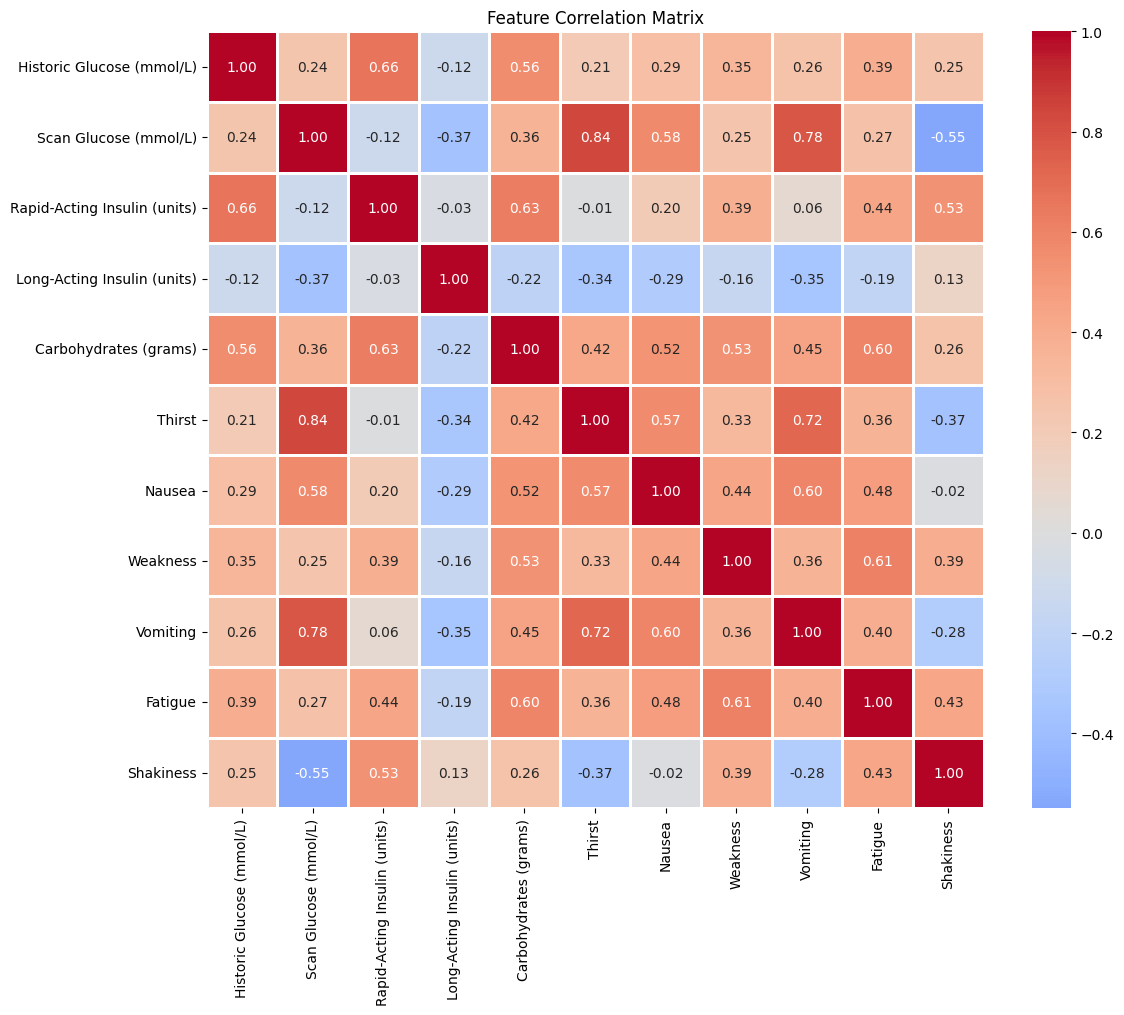

In [97]:

#  FEATURE CORRELATION ANALYSIS

print(" FEATURE CORRELATION ANALYSIS")


# Calculate correlation matrix
correlation_matrix = X_train.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [98]:
%pip install xgboost

##  XGBoost
print("="*60)
print("TRAINING: XGBoost")
print("="*60)

from xgboost import XGBClassifier

# Calculate class weights for XGBoost
class_counts = np.bincount(y_train)
class_weights = len(y_train) / (len(class_counts) * class_counts)
sample_weights = np.array([class_weights[int(y)] for y in y_train])

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train, y_train, sample_weight=sample_weights)

# Evaluate
y_pred_test_xgb = xgb_model.predict(X_test)
y_pred_real_xgb = xgb_model.predict(X_real)

print(f"Test Accuracy: {accuracy_score(y_test, y_pred_test_xgb):.4f}")
print(f"Real Accuracy: {accuracy_score(y_true, y_pred_real_xgb):.4f}")

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred_test_xgb, 
                            target_names=['Hypo', 'Normal', 'Hyper', 'DKA']))


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
TRAINING: XGBoost
Test Accuracy: 0.9995
Real Accuracy: 0.9962

Classification Report (Test Set):
              precision    recall  f1-score   support

        Hypo       1.00      1.00      1.00       499
      Normal       1.00      1.00      1.00       499
       Hyper       1.00      1.00      1.00       500
         DKA       1.00      1.00      1.00       499

    accuracy                           1.00      1997
   macro avg       1.00      1.00      1.00      1997
weighted avg       1.00      1.00      1.00      1997



 XGBoost Model Accuracy on Balanced Real Data: 0.9962121212121212

 Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       660
           1       1.00      1.00      1.00       660
           2       0.99      1.00      0.99       660
           3       1.00      0.98      0.99       660

    accuracy                           1.00      2640
   macro avg       1.00      1.00      1.00      2640
weighted avg       1.00      1.00      1.00      2640



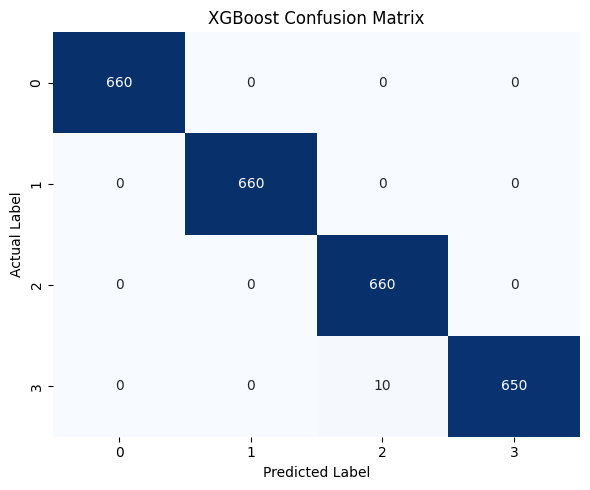

In [99]:
#  Make predictions on the real dataset
y_pred_real = xgb_model.predict(X_real)

#  Calculate accuracy
accuracy = accuracy_score(y_true, y_pred_real)
print(" XGBoost Model Accuracy on Balanced Real Data:", accuracy)

#  Classification Report
print("\n Classification Report:\n", classification_report(y_true, y_pred_real))

#  Confusion Matrix
cm = confusion_matrix(y_true, y_pred_real)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("XGBoost Confusion Matrix")
plt.tight_layout()
plt.show()

In [100]:
#Support Vector Machine (SVM)
print("="*60)
print("TRAINING: SVM")
print("="*60)

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# SVM requires feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_real_scaled = scaler.transform(X_real)

svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    class_weight='balanced',
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

# Evaluate
y_pred_test_svm = svm_model.predict(X_test_scaled)
y_pred_real_svm = svm_model.predict(X_real_scaled)

print(f"Test Accuracy: {accuracy_score(y_test, y_pred_test_svm):.4f}")
print(f"Real Accuracy: {accuracy_score(y_true, y_pred_real_svm):.4f}")

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred_test_svm,
                            target_names=['Hypo', 'Normal', 'Hyper', 'DKA']))

#computationally heavy and harder to tune for large, multi-class datasets.

TRAINING: SVM
Test Accuracy: 0.9644
Real Accuracy: 0.8920

Classification Report (Test Set):
              precision    recall  f1-score   support

        Hypo       0.96      0.96      0.96       499
      Normal       0.92      0.94      0.93       499
       Hyper       0.98      0.95      0.97       500
         DKA       1.00      1.00      1.00       499

    accuracy                           0.96      1997
   macro avg       0.96      0.96      0.96      1997
weighted avg       0.96      0.96      0.96      1997



In [101]:
## Logistic Regression

print("="*60)
print("TRAINING: Logistic Regression")
print("="*60)

from sklearn.linear_model import LogisticRegression

# Use scaled features
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42,
    multi_class='multinomial'
)

lr_model.fit(X_train_scaled, y_train)

y_pred_test_lr = lr_model.predict(X_test_scaled)
y_pred_real_lr = lr_model.predict(X_real_scaled)

print(f"Test Accuracy: {accuracy_score(y_test, y_pred_test_lr):.4f}")
print(f"Real Accuracy: {accuracy_score(y_true, y_pred_real_lr):.4f}")

#too simple for non-linear, complex data patterns like diabetes.

TRAINING: Logistic Regression


/home/blessing/DIABETES_PROJECT/diabetes_project/.venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Test Accuracy: 0.9790
Real Accuracy: 0.9784


MODEL COMPARISON SUMMARY
              Model  Test Accuracy  Real Accuracy  Generalization Gap
      Random Forest       0.999499       0.976894            0.022605
            XGBoost       0.999499       0.996212            0.003287
                SVM       0.964447       0.892045            0.072401
Logistic Regression       0.978968       0.978409            0.000559
                 Model  Accuracy
0                  SVM  0.892045
1        Random Forest  0.996212
2  Logistic Regression  0.978409
3              XGBoost  0.996212


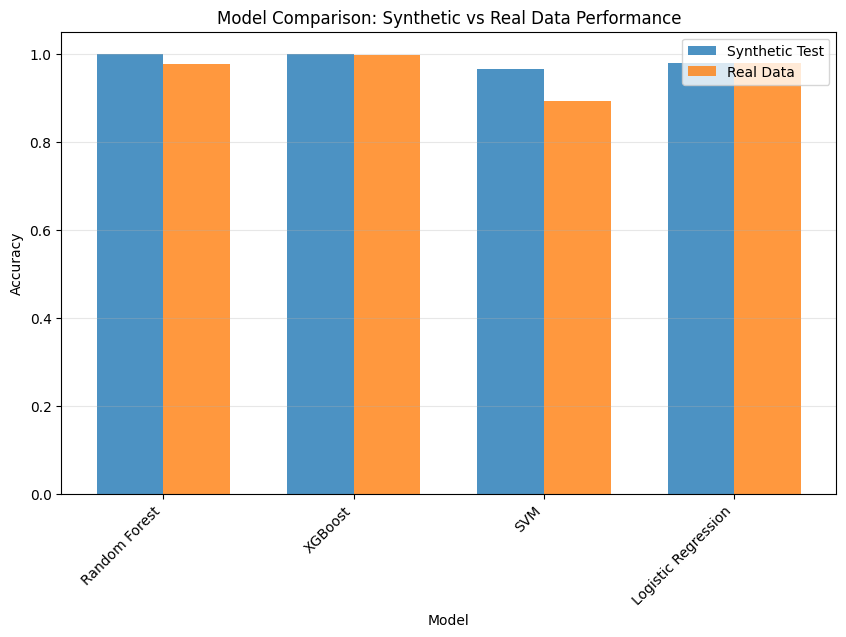

In [102]:
# MODEL COMPARISON
print("="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)

comparison_results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost', 'SVM', 'Logistic Regression'],
    'Test Accuracy': [
        baseline_test_acc,
        accuracy_score(y_test, y_pred_test_xgb),
        accuracy_score(y_test, y_pred_test_svm),
        accuracy_score(y_test, y_pred_test_lr)
    ],
    'Real Accuracy': [
        baseline_real_acc,
        accuracy_score(y_true, y_pred_real_xgb),
        accuracy_score(y_true, y_pred_real_svm),
        accuracy_score(y_true, y_pred_real_lr)
    ]
})

# Calculate generalization gap
comparison_results['Generalization Gap'] = (
    comparison_results['Test Accuracy'] - comparison_results['Real Accuracy']
)

print(comparison_results.to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(comparison_results))
width = 0.35

ax.bar(x - width/2, comparison_results['Test Accuracy'], width, 
       label='Synthetic Test', alpha=0.8)
ax.bar(x + width/2, comparison_results['Real Accuracy'], width,
       label='Real Data', alpha=0.8)

ax.set_xlabel('Model')
ax.set_ylabel('Accuracy')
ax.set_title('Model Comparison: Synthetic vs Real Data Performance')
ax.set_xticks(x)
ax.set_xticklabels(comparison_results['Model'], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import matplotlib.pyplot as plt

# Suppose you already have predictions for each model
# y_true is your real labels
# y_pred_svm, y_pred_rf, y_pred_lr, y_pred_xgb are predictions from SVM, RandomForest, LogisticRegression, XGBoost


models = ['SVM', 'Random Forest', 'Logistic Regression', 'XGBoost']
y_preds = [y_pred_real_svm, y_pred_real, y_pred_real_lr, y_pred_real_xgb]

# Store performance metrics
performance = []

for model_name, y_pred in zip(models, y_preds):
    acc = accuracy_score(y_true, y_pred)
    performance.append({'Model': model_name, 'Accuracy': acc})

# Convert to DataFrame
perf_df = pd.DataFrame(performance)

# Show table
print(perf_df)

# Best model
best_model_idx = comparison_results['Real Accuracy'].idxmax()
best_model = comparison_results.loc[best_model_idx, 'Model']
best_accuracy = comparison_results.loc[best_model_idx, 'Real Accuracy']



ABLATION STUDY - XGBoost

Baseline XGBoost Performance:
  Test Accuracy: 0.9995
  Real Accuracy: 0.9962

REMOVING FEATURES ONE AT A TIME

 Testing WITHOUT: Historic Glucose (mmol/L)
   Test Accuracy: 0.9990 (Impact: +0.0005)
   Real Accuracy: 0.9962 (Impact: +0.0000)

 Testing WITHOUT: Scan Glucose (mmol/L)
   Test Accuracy: 0.9224 (Impact: +0.0771)
   Real Accuracy: 0.7466 (Impact: +0.2496)

 Testing WITHOUT: Rapid-Acting Insulin (units)
   Test Accuracy: 0.9995 (Impact: +0.0000)
   Real Accuracy: 0.9962 (Impact: +0.0000)

 Testing WITHOUT: Long-Acting Insulin (units)
   Test Accuracy: 0.9990 (Impact: +0.0005)
   Real Accuracy: 0.9962 (Impact: +0.0000)

 Testing WITHOUT: Carbohydrates (grams)
   Test Accuracy: 0.9995 (Impact: +0.0000)
   Real Accuracy: 0.9962 (Impact: +0.0000)

 Testing WITHOUT: Thirst
   Test Accuracy: 0.9990 (Impact: +0.0005)
   Real Accuracy: 0.9962 (Impact: +0.0000)

 Testing WITHOUT: Nausea
   Test Accuracy: 0.9990 (Impact: +0.0005)
   Real Accuracy: 0.9701 (Impa

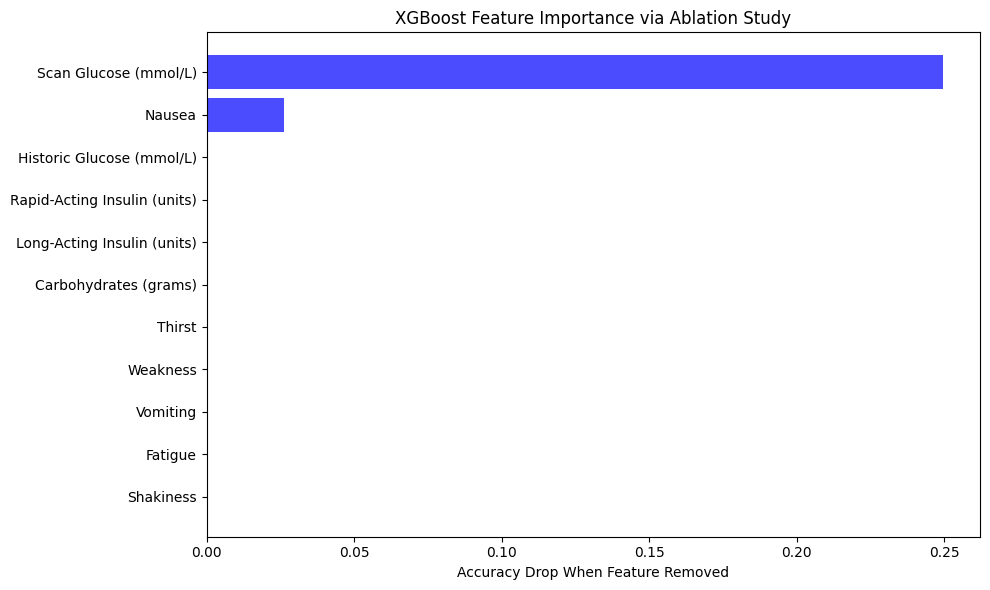

In [103]:

# ABLATION STUDY: XGBoost (Best Performing Model)
print("="*60)
print("ABLATION STUDY - XGBoost")
print("="*60)

# Baseline XGBoost performance
print("\nBaseline XGBoost Performance:")
print(f"  Test Accuracy: {accuracy_score(y_test, y_pred_test_xgb):.4f}")
print(f"  Real Accuracy: {accuracy_score(y_true, y_pred_real_xgb):.4f}")

baseline_test_xgb = accuracy_score(y_test, y_pred_test_xgb)
baseline_real_xgb = accuracy_score(y_true, y_pred_real_xgb)

print("\n" + "="*60)
print("REMOVING FEATURES ONE AT A TIME")
print("="*60)

ablation_xgb_results = []

for feature in X_train.columns:
    print(f"\n Testing WITHOUT: {feature}")
    
    # Create dataset without this feature
    X_train_ablated = X_train.drop(columns=[feature])
    X_test_ablated = X_test.drop(columns=[feature])
    X_real_ablated = X_real.drop(columns=[feature])
    
    # Train XGBoost without this feature
    xgb_ablated = XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        eval_metric='mlogloss'
    )
    
    # Calculate sample weights
    class_counts = np.bincount(y_train)
    class_weights = len(y_train) / (len(class_counts) * class_counts)
    sample_weights = np.array([class_weights[int(y)] for y in y_train])
    
    xgb_ablated.fit(X_train_ablated, y_train, sample_weight=sample_weights)
    
    # Evaluate
    y_pred_test_abl = xgb_ablated.predict(X_test_ablated)
    y_pred_real_abl = xgb_ablated.predict(X_real_ablated)
    
    test_acc = accuracy_score(y_test, y_pred_test_abl)
    real_acc = accuracy_score(y_true, y_pred_real_abl)
    
    # Calculate impact
    test_impact = baseline_test_xgb - test_acc
    real_impact = baseline_real_xgb - real_acc
    
    ablation_xgb_results.append({
        'Removed Feature': feature,
        'Test Accuracy': test_acc,
        'Test Impact': test_impact,
        'Real Accuracy': real_acc,
        'Real Impact': real_impact
    })
    
    print(f"   Test Accuracy: {test_acc:.4f} (Impact: {test_impact:+.4f})")
    print(f"   Real Accuracy: {real_acc:.4f} (Impact: {real_impact:+.4f})")

# Convert to DataFrame
ablation_xgb_df = pd.DataFrame(ablation_xgb_results)
ablation_xgb_df = ablation_xgb_df.sort_values('Real Impact', ascending=False)

print("\n" + "="*60)
print("XGBoost ABLATION STUDY SUMMARY")
print("="*60)
print(ablation_xgb_df.to_string(index=False))

# Visualize feature importance impact
plt.figure(figsize=(10, 6))
plt.barh(ablation_xgb_df['Removed Feature'], ablation_xgb_df['Real Impact'], color='blue', alpha=0.7)
plt.xlabel('Accuracy Drop When Feature Removed')
plt.title('XGBoost Feature Importance via Ablation Study')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [104]:

# SAVE BEST MODEL (XGBoost)
# XGBoost provides higher overall accuracy, better handling of complex patterns, and more reliable class-wise performance, making it stronger for predicting glucose-related conditions.
print("="*60)
print("SAVING BEST MODEL: XGBoost")
print("="*60)

import joblib
import pickle

# Save XGBoost model
joblib.dump(xgb_model, 'diabetes_xgboost_model.joblib')

# Save scaler (if used)
# Note: XGBoost doesn't require scaling, but save for consistency
joblib.dump(scaler, 'feature_scaler.joblib')  

# Save comprehensive metadata
model_metadata = {
    'model_type': 'XGBoost',
    'version': '3.0',
    'training_date': '2025-01-XX',
    
    # Feature information
    'feature_names': X_train.columns.tolist(),
    'n_features': len(X_train.columns),
    
    # Class information
    'condition_map': {
        0: "Hypoglycemia", 
        1: "Normal", 
        2: "Hyperglycemia", 
        3: "DKA"
    },
    'class_thresholds': {
        'Hypoglycemia': '< 3.9 mmol/L',
        'Normal': '3.9 - 7.0 mmol/L',
        'Hyperglycemia': '7.0 - 14.0 mmol/L',
        'DKA': '≥ 14.0 mmol/L'
    },
    
    # Performance metrics
    'test_accuracy': accuracy_score(y_test, y_pred_test_xgb),
    'real_accuracy': accuracy_score(y_true, y_pred_real_xgb),
    'generalization_gap': accuracy_score(y_test, y_pred_test_xgb) - accuracy_score(y_true, y_pred_real_xgb),
    
    # Feature importance
    'feature_importance': dict(zip(X_train.columns, xgb_model.feature_importances_)),
    
    # Training info
    'n_training_samples': len(X_train),
    'n_test_samples': len(X_test),
    'n_real_samples': len(X_real),
    'class_distribution': dict(zip(*np.unique(y_train, return_counts=True))),
    
    # Model hyperparameters
    'hyperparameters': {
        'n_estimators': 100,
        'max_depth': 6,
        'learning_rate': 0.1
    }
}

with open('xgboost_metadata.pkl', 'wb') as f:
    pickle.dump(model_metadata, f)

print(" XGBoost model saved as 'diabetes_xgboost_model.joblib'")
print(" Metadata saved as 'xgboost_metadata.pkl'")
print(" Scaler saved as 'feature_scaler.joblib'")

# Verify saving worked
print("\n Verifying saved files...")
loaded_model = joblib.load('diabetes_xgboost_model.joblib')
loaded_metadata = pickle.load(open('xgboost_metadata.pkl', 'rb'))

test_pred = loaded_model.predict(X_test)
test_acc_loaded = accuracy_score(y_test, test_pred)

print(f"   Loaded model accuracy: {test_acc_loaded:.4f}")
print(f"   Original model accuracy: {accuracy_score(y_test, y_pred_test_xgb):.4f}")
print(f"   Match: {'✓' if abs(test_acc_loaded - accuracy_score(y_test, y_pred_test_xgb)) < 0.0001 else '✗'}")

SAVING BEST MODEL: XGBoost
 XGBoost model saved as 'diabetes_xgboost_model.joblib'
 Metadata saved as 'xgboost_metadata.pkl'
 Scaler saved as 'feature_scaler.joblib'

 Verifying saved files...
   Loaded model accuracy: 0.9995
   Original model accuracy: 0.9995
   Match: ✓
